# Predicting the Next Franchise
## When a Kids Show Becomes a Business

**Dataset:** Animated shows (3,600+ titles) · Amazon Toys US · Netflix catalog · YouTube Data API v3  
**Goal:** Identify what combination of show characteristics, merchandise presence, and organic reach predicts a global kids franchise — not just a good show  
**Stack:** Python · Pandas · Scikit-learn · XGBoost · Matplotlib · Plotly · YouTube Data API v3  
**Author:** David Hernández — Data Analytics Portfolio

---

## Table of Contents

| Section | Description |
|---|---|
| 0 | Imports & Configuration |
| 1 | Load Kids Shows Dataset |
| 1.1 | YouTube Signal Enrichment via API |
| 1.1b | YouTube Re-run (quota recovery) |
| 2 | Amazon Toys US — Merchandise Signal |
| 3 | Netflix Kids — Streaming Reach |
| 4 | Data Integration — Building the Franchise Dataset |
| 5 | Merchandise Opportunity Analysis |
| 5.1 | Feature Engineering for ML |
| 6 | Model Training — RF vs XGBoost |
| 6.1 | Clean Feature Set + Leakage Check |
| 7 | Feature Importance |
| 7.1 | SHAP Analysis |
| 7.2 | Franchise Probability Scatter |
| 8 | Export — Analysis Model + Dashboard Model |
| 8.0 | Franchise Concept Analyzer — Field Reference |


In [1]:
# ============================================
# SECTION 0 — Imports & Configuration
# ============================================

import os
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import googleapiclient.discovery
import joblib
import warnings

from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_recall_curve)

warnings.filterwarnings('ignore')

# ── Adult shows exclusion list (used in Sections 3.2 and 4.2) ────────────
ADULT_SHOWS = [
    'Rick and Morty', 'Family Guy', 'South Park', 'American Dad!',
    'Futurama', "Bob's Burgers", 'Archer', 'BoJack Horseman',
    'Big Mouth', 'Disenchantment', 'INVINCIBLE', 'Velma',
    'F is for Family', 'Paradise PD', 'Ugly Americans'
]

# ── API Keys ──────────────────────────────────────────────────────────────
load_dotenv()
API_KEY   = os.getenv("API_KEY")
API_KEY_2 = os.getenv("API_KEY_2")
API_KEY_3 = os.getenv("API_KEY_3")
API_KEY_4 = os.getenv("API_KEY_4")
API_KEY_5 = os.getenv("API_KEY_5")
API_KEY_6 = os.getenv("API_KEY_6")
API_KEY_7 = os.getenv("API_KEY_7")
API_KEY_8 = os.getenv("API_KEY_8")
API_KEY_9  = os.getenv("API_KEY_9")
API_KEY_10 = os.getenv("API_KEY_10")
API_KEY_11 = os.getenv("API_KEY_11")

# ── Plot style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_SUCCESS = '#2ecc71'
COLOR_FAIL    = '#e74c3c'
COLOR_NEUTRAL = 'steelblue'

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_DIR    = r'C:\Users\jdhernandezd\Documents\IRONHACK\Portfolio'
PROJECT_DIR = os.path.join(BASE_DIR, 'Predicting the Next Franchise')
P1_DIR      = os.path.join(BASE_DIR, 'Animated TV Shows Around the World (1948 - 2023)')
os.chdir(PROJECT_DIR)

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42

print("✅ Section 0 ready")
print(f"   Pandas:  {pd.__version__}")
print(f"   Sklearn: ready")
print(f"   API keys loaded: {sum(1 for k in [API_KEY, API_KEY_2, API_KEY_3, API_KEY_4, API_KEY_5, API_KEY_6, API_KEY_7, API_KEY_8, API_KEY_9, API_KEY_10, API_KEY_11] if k)}/11")

✅ Section 0 ready
   Pandas:  2.3.3
   Sklearn: ready
   API keys loaded: 11/11


In [2]:
# ============================================
# SECTION 1 — Load Kids Shows Dataset
# ============================================
# Entry point: layer2 from Project 1 — already filtered, enriched with IMDb.
# No need to re-filter here — Project 1 already did that work.

df_kids = pd.read_csv(os.path.join(P1_DIR, 'layer2_ml_dataset_clean.csv'))

print(f"✅ Kids shows loaded: {len(df_kids)}")
print(f"\nTop 20 by numVotes:")
print(df_kids[['title', 'averageRating', 'numVotes', 'seasons', 'country']]
      .sort_values('numVotes', ascending=False)
      .head(20)
      .to_string(index=False))


✅ Kids shows loaded: 1389

Top 20 by numVotes:
                      title  averageRating  numVotes  seasons       country
             Rick and Morty            9.0  693882.0      5.0 United States
               The Simpsons            8.6  468353.0     33.0 United States
                 South Park            8.7  443748.0     23.0 United States
                     Arcane            9.0  443021.0      1.0 United States
 Avatar: The Last Airbender            9.3  440802.0      3.0 United States
                 Family Guy            8.1  388463.0     20.0 United States
                 Invincible            8.7  334153.0      1.0 United States
                   Futurama            8.5  278642.0      7.0 United States
              Gravity Falls            8.9  177994.0      2.0 United States
                What If...?            7.3  160176.0      1.0 United States
        The Legend of Korra            8.3  150761.0      4.0 United States
              American Dad!            7.

In [3]:
# ============================================
# SECTION 1.1 — YouTube Signal Enrichment
# ============================================

CHECKPOINT_FILE = 'yt_enrichment_progress.csv'
BATCH_SIZE      = 399   # Exact remaining for final run
SLEEP_BETWEEN   = 1.0

# ── Keys for today (3, 4, 5 are fresh) ───────────────────────────────────

KEYS_TODAY = [API_KEY, API_KEY_2, API_KEY_3, API_KEY_4, 
              API_KEY_5, API_KEY_6, API_KEY_7, API_KEY_8]

# ── Load checkpoint ───────────────────────────────────────────────────────
if os.path.exists(CHECKPOINT_FILE):
    df_yt = pd.read_csv(CHECKPOINT_FILE)
    done_titles = set(df_yt['title'].tolist())
    print(f"♻️  Resuming — {len(done_titles)} shows already processed")
else:
    df_yt = pd.DataFrame()
    done_titles = set()
    print("🆕 Starting fresh")

# ── Shows to process ──────────────────────────────────────────────────────
titles_to_process = [t for t in df_kids['title'].tolist() if t not in done_titles]
titles_this_run   = titles_to_process[:BATCH_SIZE]

print(f"   Shows remaining:    {len(titles_to_process)}")
print(f"   Processing now:     {len(titles_this_run)}")
print(f"   Keys rotating:      every 90 shows")
print()

# ── Extraction loop ───────────────────────────────────────────────────────
results = []

for i, title in enumerate(titles_this_run):

    # ── Rotate key every 90 shows ─────────────────────────────────────────
    key_index = min(i // 90, len(KEYS_TODAY) - 1)
    youtube   = googleapiclient.discovery.build(
        "youtube", "v3",
        developerKey=KEYS_TODAY[key_index],
        cache_discovery=False
    )

    try:
        search = youtube.search().list(
            q=f"{title} cartoon",
            part="snippet",
            type="video",
            maxResults=10,
            order="viewCount"
        ).execute()

        video_ids = [item['id']['videoId'] for item in search.get('items', [])]

        if not video_ids:
            results.append({
                'title':                title,
                'yt_has_content':       0,
                'yt_top10_total_views': 0,
                'yt_top10_avg_views':   0,
                'yt_video_count':       0,
            })
            continue

        stats = youtube.videos().list(
            part="statistics",
            id=','.join(video_ids)
        ).execute()

        views = [int(item['statistics'].get('viewCount', 0))
                 for item in stats.get('items', [])]

        results.append({
            'title':                title,
            'yt_has_content':       1,
            'yt_top10_total_views': sum(views),
            'yt_top10_avg_views':   int(sum(views) / len(views)) if views else 0,
            'yt_video_count':       len(views),
        })

        if (i + 1) % 10 == 0:
            print(f"  [{i+1:3d}/{len(titles_this_run)}] key{key_index+3} · {title[:38]:<38} → {sum(views):,} views")

        time.sleep(SLEEP_BETWEEN)

    except Exception as e:
        print(f"  ⚠️  Error on '{title}': {e}")
        results.append({
            'title':                title,
            'yt_has_content':       0,
            'yt_top10_total_views': 0,
            'yt_top10_avg_views':   0,
            'yt_video_count':       0,
        })

# ── Save checkpoint ───────────────────────────────────────────────────────
df_batch = pd.DataFrame(results)
df_yt    = pd.concat([df_yt, df_batch], ignore_index=True)
df_yt.to_csv(CHECKPOINT_FILE, index=False)

print(f"\n✅ Batch complete — {len(df_batch)} shows processed")
print(f"   Total in checkpoint: {len(df_yt)}")
print(f"   Remaining:           {len(titles_to_process) - len(titles_this_run)}")

# ── Re-merge df_kids with updated checkpoint ─────────────────────────────
df_kids = df_kids.drop(columns=['yt_has_content', 'yt_top10_total_views',
                                 'yt_top10_avg_views', 'yt_video_count'], errors='ignore')
df_kids = df_kids.merge(df_yt, on='title', how='left')
df_kids['yt_has_content']       = df_kids['yt_has_content'].fillna(0)
df_kids['yt_top10_total_views'] = df_kids['yt_top10_total_views'].fillna(0)
df_kids['yt_top10_avg_views']   = df_kids['yt_top10_avg_views'].fillna(0)
df_kids['yt_video_count']       = df_kids['yt_video_count'].fillna(0)

print(f"\n🎯 df_kids updated with final YouTube data")
print(f"   Shows with YT content: {int(df_kids['yt_has_content'].sum())}")
print(f"   Total views captured:  {df_kids['yt_top10_total_views'].sum():,.0f}")
print(f"\n   Top 5 by total views:")
print(df_kids.sort_values('yt_top10_total_views', ascending=False)
      .head(5)[['title', 'yt_top10_total_views']].to_string(index=False))

♻️  Resuming — 1382 shows already processed
   Shows remaining:    0
   Processing now:     0
   Keys rotating:      every 90 shows


✅ Batch complete — 0 shows processed
   Total in checkpoint: 1389
   Remaining:           0

🎯 df_kids updated with final YouTube data
   Shows with YT content: 1405
   Total views captured:  635,209,349,313

   Top 5 by total views:
             title  yt_top10_total_views
Talking Tom Shorts           11642241561
         Clay Kids           10081030109
            Sheeep            8576128774
           Spider!            8319027594
   Talking Friends            8051103993


In [4]:
# ============================================
# SECTION 1.1b — YouTube Re-run (failed shows)
# ============================================

CHECKPOINT_FILE = 'yt_enrichment_progress.csv'
SLEEP_BETWEEN   = 1.0
KEYS_TODAY      = [API_KEY_9, API_KEY_10, API_KEY_11]

# ── Load checkpoint and find failed shows ────────────────────────────────
df_yt       = pd.read_csv(CHECKPOINT_FILE)
zero_titles = df_yt[df_yt['yt_has_content'] == 0]['title'].tolist()
titles_this_run = zero_titles

print(f"🔄 Re-run mode — {len(titles_this_run)} shows with 0 views")
print(f"   Keys available: {len(KEYS_TODAY)}")
print()

# ── Extraction loop ───────────────────────────────────────────────────────
results = []

for i, title in enumerate(titles_this_run):
    key_index = min(i // 90, len(KEYS_TODAY) - 1)
    youtube   = googleapiclient.discovery.build(
        "youtube", "v3",
        developerKey=KEYS_TODAY[key_index],
        cache_discovery=False
    )

    try:
        search = youtube.search().list(
            q=f"{title} cartoon",
            part="snippet",
            type="video",
            maxResults=10,
            order="viewCount"
        ).execute()

        video_ids = [item['id']['videoId'] for item in search.get('items', [])]

        if not video_ids:
            results.append({'title': title, 'yt_has_content': 0,
                            'yt_top10_total_views': 0, 'yt_top10_avg_views': 0,
                            'yt_video_count': 0})
            continue

        stats = youtube.videos().list(
            part="statistics",
            id=','.join(video_ids)
        ).execute()

        views = [int(item['statistics'].get('viewCount', 0))
                 for item in stats.get('items', [])]

        results.append({
            'title':                title,
            'yt_has_content':       1,
            'yt_top10_total_views': sum(views),
            'yt_top10_avg_views':   int(sum(views) / len(views)) if views else 0,
            'yt_video_count':       len(views),
        })

        if (i + 1) % 10 == 0:
            print(f"  [{i+1:3d}/{len(titles_this_run)}] key{key_index+9} · {title[:38]:<38} → {sum(views):,} views")

        time.sleep(SLEEP_BETWEEN)

    except Exception as e:
        print(f"  ⚠️  Error on '{title}': {e}")
        results.append({'title': title, 'yt_has_content': 0,
                        'yt_top10_total_views': 0, 'yt_top10_avg_views': 0,
                        'yt_video_count': 0})

# ── Update checkpoint — replace rows, don't append ───────────────────────
df_rerun = pd.DataFrame(results)
df_yt    = df_yt[~df_yt['title'].isin(df_rerun['title'])]  # remove old 0-rows
df_yt    = pd.concat([df_yt, df_rerun], ignore_index=True)
df_yt.to_csv(CHECKPOINT_FILE, index=False)

recovered = df_rerun[df_rerun['yt_has_content'] == 1]
still_zero = df_rerun[df_rerun['yt_has_content'] == 0]

print(f"\n✅ Re-run complete")
print(f"   Recovered:   {len(recovered)} shows now have views")
print(f"   Still 0:     {len(still_zero)} shows — likely no YouTube content")
print(f"\nTop recovered by views:")
print(recovered.sort_values('yt_top10_total_views', ascending=False)
      .head(10)[['title', 'yt_top10_total_views']].to_string(index=False))

🔄 Re-run mode — 0 shows with 0 views
   Keys available: 3



KeyError: 'title'

In [5]:
# ============================================
# SECTION 2 — Amazon Products 2023
# ============================================

df_categories = pd.read_csv('amazon_categories.csv')
print(f"Categories shape: {df_categories.shape}")
print(f"Columns: {df_categories.columns.tolist()}")
print(f"\nAll categories:")
print(df_categories.to_string())

Categories shape: (248, 2)
Columns: ['id', 'category_name']

All categories:
      id                                     category_name
0      1                          Beading & Jewelry Making
1      2                                 Fabric Decorating
2      3                       Knitting & Crochet Supplies
3      4                              Printmaking Supplies
4      5                  Scrapbooking & Stamping Supplies
5      6                                   Sewing Products
6      7                              Craft & Hobby Fabric
7      8                               Needlework Supplies
8      9                     Arts, Crafts & Sewing Storage
9     10                  Painting, Drawing & Art Supplies
10    11                        Craft Supplies & Materials
11    12                            Gift Wrapping Supplies
12    13                                 Party Decorations
13    14                 Automotive Paint & Paint Supplies
14    15         Heavy Duty & Commerci

In [6]:
# ============================================
# SECTION 2.1 — Load Toys Only (memory efficient)
# ============================================
# Target category IDs — show-related toys
TOY_CATEGORY_IDS = [217, 221, 229, 270, 218, 225, 220, 219]

chunks = []
for chunk in pd.read_csv('amazon_products.csv', chunksize=100000):
    filtered = chunk[chunk['category_id'].isin(TOY_CATEGORY_IDS)]
    chunks.append(filtered)

df_toys = pd.concat(chunks, ignore_index=True)

print(f"✅ Toy products loaded: {len(df_toys)}")
print(f"Columns: {df_toys.columns.tolist()}")
print(f"\nProducts per category:")
print(df_toys['category_id'].value_counts())

✅ Toy products loaded: 71466
Columns: ['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth']

Products per category:
category_id
270    20846
219     8313
217     7973
225     7585
221     7521
218     7432
220     6398
229     5398
Name: count, dtype: int64


In [7]:
# ============================================
# SECTION 2.2 — Cross-reference Shows vs Toys
# ============================================
# Matching rules:
#   - Skip single-word titles (too generic)
#   - Use full title for short names (≤3 words), first 3 words for long ones
#   - Minimum 4 characters to avoid garbage matches

show_titles = df_kids['title'].dropna().tolist()

results_clean = []
for show in show_titles:
    words = show.split()

    if len(words) < 2:
        continue

    keywords = show if len(words) <= 3 else ' '.join(words[:3])

    if len(keywords) < 4:
        continue

    hits = df_toys[df_toys['title'].str.contains(keywords, case=False, na=False)]

    if len(hits) > 0:
        results_clean.append({
            'show':              show,
            'keywords_used':     keywords,
            'toy_products':      len(hits),
            'avg_stars':         round(hits['stars'].mean(), 2),
            'total_reviews':     hits['reviews'].sum(),
            'bestsellers':       hits['isBestSeller'].sum(),
            'bought_last_month': hits['boughtInLastMonth'].sum()
        })

df_merch = pd.DataFrame(results_clean).sort_values('toy_products', ascending=False)

print(f"✅ Shows with merchandise: {len(df_merch)} out of {len(show_titles)}")
print(f"\nTop 20 by toy products:")
print(df_merch.head(20).to_string(index=False))


✅ Shows with merchandise: 181 out of 1405

Top 20 by toy products:
                               show        keywords_used  toy_products  avg_stars  total_reviews  bestsellers  bought_last_month
                         PAW Patrol           PAW Patrol           235       4.39         115552            0              48550
                       Mickey Mouse         Mickey Mouse           159       4.33          68386            0              30250
       Teenage Mutant Ninja Turtles Teenage Mutant Ninja           142       4.09           2397            0              36300
       Teenage Mutant Ninja Turtles Teenage Mutant Ninja           142       4.09           2397            0              36300
       Teenage Mutant Ninja Turtles Teenage Mutant Ninja           142       4.09           2397            0              36300
       Teenage Mutant Ninja Turtles Teenage Mutant Ninja           142       4.09           2397            0              36300
                 Sonic the Hed

In [8]:
# ============================================
# SECTION 2.3 — Deduplicate and validate
# ============================================

# Drop duplicates by show title
df_merch = df_merch.drop_duplicates(subset='show').reset_index(drop=True)

# Flag potentially unreliable matches — keywords under 10 chars are risky
df_merch['match_reliable'] = df_merch['keywords_used'].apply(
    lambda x: len(x) >= 10
)

print(f"✅ Clean merchandise dataset: {len(df_merch)} shows")
print(f"   Reliable matches:   {df_merch['match_reliable'].sum()}")
print(f"   Unreliable matches: {(~df_merch['match_reliable']).sum()}")

print(f"\nTop 20 reliable matches only:")
print(df_merch[df_merch['match_reliable']]
      .sort_values('bought_last_month', ascending=False)
      .head(20)[['show', 'toy_products', 'avg_stars', 'total_reviews', 'bought_last_month']]
      .to_string(index=False))

✅ Clean merchandise dataset: 161 shows
   Reliable matches:   149
   Unreliable matches: 12

Top 20 reliable matches only:
                               show  toy_products  avg_stars  total_reviews  bought_last_month
                         PAW Patrol           235       4.39         115552              48550
     Spidey and His Amazing Friends           101       4.42          20056              38600
                  Gabby's Dollhouse            69       4.04          36948              36500
       Teenage Mutant Ninja Turtles           142       4.09           2397              36300
                       Mickey Mouse           159       4.33          68386              30250
                       Polly Pocket           112       4.53          82153              28050
                 Sonic the Hedgehog           133       4.24          23714              19250
                 The Little Mermaid            58       4.20           4028              18800
Lego Star Wars: The Yo

In [9]:
# ============================================
# SECTION 2.4 — Save & Merge with Shows Dataset
# ============================================

# Save merchandise dataset
df_merch.to_csv('merchandise_signal.csv', index=False)
print("✅ merchandise_signal.csv saved")

# Merge with kids shows dataset
df_franchise = df_kids.merge(
    df_merch[['show', 'toy_products', 'avg_stars', 
              'total_reviews', 'bought_last_month', 'match_reliable']],
    left_on='title',
    right_on='show',
    how='left'
).drop(columns='show')

# Flag shows with merchandise presence
df_franchise['has_merch'] = df_franchise['toy_products'].notna().astype(int)
df_franchise['bought_last_month'] = df_franchise['bought_last_month'].fillna(0)
df_franchise['toy_products']      = df_franchise['toy_products'].fillna(0)

print(f"\n✅ Franchise dataset: {len(df_franchise)} shows")
print(f"   With merchandise:    {df_franchise['has_merch'].sum()}")
print(f"   Without merchandise: {(df_franchise['has_merch']==0).sum()}")

print(f"\nTop 10 by bought_last_month:")
print(df_franchise[df_franchise['has_merch']==1]
      .sort_values('bought_last_month', ascending=False)
      .head(10)[['title', 'averageRating', 'seasons', 'bought_last_month', 'toy_products']]
      .to_string(index=False))

✅ merchandise_signal.csv saved

✅ Franchise dataset: 1405 shows
   With merchandise:    181
   Without merchandise: 1224

Top 10 by bought_last_month:
                         title  averageRating  seasons  bought_last_month  toy_products
                    PAW Patrol            6.1      7.0            48550.0         235.0
Spidey and His Amazing Friends            5.8      1.0            38600.0         101.0
             Gabby's Dollhouse            7.1      4.0            36500.0          69.0
  Teenage Mutant Ninja Turtles            7.9     10.0            36300.0         142.0
  Teenage Mutant Ninja Turtles            7.9      5.0            36300.0         142.0
  Teenage Mutant Ninja Turtles            7.9     10.0            36300.0         142.0
  Teenage Mutant Ninja Turtles            7.9      5.0            36300.0         142.0
                  Mickey Mouse            8.1      5.0            30250.0         159.0
                  Polly Pocket            5.9      3.0   

In [10]:
# ============================================
# SECTION 2.5 — Fix TMNT duplicate in franchise dataset
# ============================================
# Same show, different season counts — keep the one with more seasons

df_franchise = (
    df_franchise
    .sort_values('seasons', ascending=False)
    .drop_duplicates(subset=['title', 'bought_last_month'], keep='first')
    .reset_index(drop=True)
)

print(f"✅ Franchise dataset after dedup: {len(df_franchise)} shows")
print(f"\nTop 10 by bought_last_month:")
print(df_franchise[df_franchise['has_merch']==1]
      .sort_values('bought_last_month', ascending=False)
      .head(10)[['title', 'averageRating', 'seasons', 'bought_last_month', 'toy_products']]
      .to_string(index=False))

✅ Franchise dataset after dedup: 1382 shows

Top 10 by bought_last_month:
                         title  averageRating  seasons  bought_last_month  toy_products
                    PAW Patrol            6.1      7.0            48550.0         235.0
Spidey and His Amazing Friends            5.8      1.0            38600.0         101.0
             Gabby's Dollhouse            7.1      4.0            36500.0          69.0
  Teenage Mutant Ninja Turtles            7.9     10.0            36300.0         142.0
                  Mickey Mouse            8.1      5.0            30250.0         159.0
                  Polly Pocket            5.9      3.0            28050.0         112.0
                     Peppa Pig            6.2      7.0            19900.0          95.0
            Sonic the Hedgehog            6.8      2.0            19250.0         133.0
            The Little Mermaid            6.8      3.0            18800.0          58.0
                      Iron Man            6.5 

In [11]:
# ============================================
# SECTION 3 — Netflix Kids Dataset
# ============================================

df_netflix = pd.read_csv('netflix_tv_shows_detailed_up_to_2025.csv')

print(f"Shape: {df_netflix.shape}")
print(f"\nColumns: {df_netflix.columns.tolist()}")
print(f"\nFirst 3 rows:")
df_netflix.head(3)

Shape: (16000, 16)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'language', 'description', 'popularity', 'vote_count', 'vote_average']

First 3 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600


In [12]:
# ============================================
# SECTION 3.1 — Explore Netflix Dataset
# ============================================

# What ratings exist? (TV-Y, TV-G = kids content)
print("Content ratings distribution:")
print(df_netflix['rating'].value_counts().head(15))

print("\nGenres sample:")
print(df_netflix['genres'].value_counts().head(15))

print("\nNulls:")
print(df_netflix.isnull().sum())

print("\nPopularity stats:")
print(df_netflix['popularity'].describe())

Content ratings distribution:
rating
0.0     3673
7.0      773
8.0      753
6.0      583
10.0     471
7.5      412
7.7      329
7.2      326
7.3      323
7.8      313
9.0      300
7.4      287
5.0      286
6.5      282
7.6      274
Name: count, dtype: int64

Genres sample:
genres
Drama                                              2744
Reality                                            1104
Comedy                                             1068
Comedy, Drama                                       516
Documentary                                         464
Drama, Comedy                                       400
Talk                                                329
Animation, Comedy                                   311
Drama, Crime                                        241
Drama, Family                                       240
Crime, Drama                                        226
Drama, Mystery                                      224
Animation, Action & Adventure, Sci-Fi & Fantasy

In [13]:
# ============================================
# SECTION 3.2 — Strict Kids Filter
# ============================================
# 'Family' is too broad — includes soap operas and reality shows
# 'Animation' + 'Kids' are the reliable signals
# ADULT_SHOWS excludes known adult animation not caught by genre filters

df_netflix_kids = df_netflix[
    df_netflix['genres'].str.contains('Animation|Kids', case=False, na=False) &
    ~df_netflix['genres'].str.contains('Adult|Stand-Up|Talk|Reality|Soap|Crime|Horror', case=False, na=False) &
    ~df_netflix['title'].str.upper().isin([s.upper() for s in ADULT_SHOWS])
].copy().reset_index(drop=True)

print(f"✅ Netflix kids shows (strict): {len(df_netflix_kids)}")

print(f"\nTop 15 by popularity:")
print(df_netflix_kids[['title', 'popularity', 'vote_average', 'vote_count', 'duration']]
      .sort_values('popularity', ascending=False)
      .head(15)
      .to_string(index=False))

✅ Netflix kids shows (strict): 2626

Top 15 by popularity:
                                  title  popularity  vote_average  vote_count  duration
                          Solo Leveling    1781.257         8.526         797 1 Seasons
                        Teen Titans Go!     952.042         6.600         640 1 Seasons
                      Dragon Ball DAIMA     908.731         8.144         380 1 Seasons
                         The Loud House     583.649         7.800         534 1 Seasons
                     Craig of the Creek     563.129         8.100         239 1 Seasons
           The Amazing World of Gumball     561.077         8.500        1472 1 Seasons
                         Beyblade Burst     555.045         8.300         321 1 Seasons
                       New Looney Tunes     554.739         7.000         145 1 Seasons
                          SAKAMOTO DAYS     545.024         8.200          94 1 Seasons
                             PAW Patrol     512.468         7

In [14]:
# ============================================
# SECTION 3.3 — Cross-reference Netflix vs Franchise Dataset
# ============================================

# Reload from checkpoint to avoid duplicate columns if cell is re-run
df_franchise = pd.read_csv('franchise_dataset.csv')

# Normalize titles for matching
df_netflix_kids['title_clean'] = df_netflix_kids['title'].str.lower().str.strip()
df_franchise['title_clean']    = df_franchise['title'].str.lower().str.strip()

# Merge
df_franchise = df_franchise.merge(
    df_netflix_kids[['title_clean', 'popularity', 'vote_average', 
                      'vote_count', 'duration']],
    on='title_clean',
    how='left'
).rename(columns={
    'popularity':     'netflix_popularity',
    'vote_average':   'netflix_vote_avg',
    'vote_count':     'netflix_vote_count',
    'duration':       'netflix_duration'
})

# Flag shows on Netflix
df_franchise['on_netflix'] = df_franchise['netflix_popularity'].notna().astype(int)
df_franchise['netflix_popularity'] = df_franchise['netflix_popularity'].fillna(0)

print(f"✅ Shows found on Netflix: {df_franchise['on_netflix'].sum()}")
print(f"   Not on Netflix:         {(df_franchise['on_netflix']==0).sum()}")

print(f"\nTop 10 franchises on Netflix by popularity:")
print(df_franchise[df_franchise['on_netflix']==1]
      .sort_values('netflix_popularity', ascending=False)
      .head(10)[['title', 'averageRating', 'bought_last_month', 'netflix_popularity']]
      .to_string(index=False))

✅ Shows found on Netflix: 336
   Not on Netflix:         1048

Top 10 franchises on Netflix by popularity:
                                  title  averageRating  bought_last_month  netflix_popularity
                        Teen Titans Go!            5.8                0.0             952.042
                         The Loud House            6.9                0.0             583.649
                     Craig of the Creek            7.6                0.0             563.129
           The Amazing World of Gumball            8.4                0.0             561.077
                       New Looney Tunes            5.8                0.0             554.739
                             PAW Patrol            6.1            48550.0             512.468
Miraculous: Tales of Ladybug & Cat Noir            7.5              300.0             512.439
                           Regular Show            8.6                0.0             426.107
           ALVINNN!!! and the Chipmunks        

In [15]:
# ============================================
# SECTION 4 — Final Dataset Summary
# ============================================

print("📊 FRANCHISE DATASET — FINAL STATE")
print("=" * 45)
print(f"Total shows:              {len(df_franchise)}")
print(f"With IMDb rating:         {df_franchise['averageRating'].notna().sum()}")
print(f"With merchandise signal:  {df_franchise['has_merch'].sum()}")
print(f"On Netflix:               {df_franchise['on_netflix'].sum()}")
print(f"Franchise target (1):     {df_franchise['is_franchise'].sum()}")
print(f"Non-franchise (0):        {(df_franchise['is_franchise']==0).sum()}")
print(f"Class balance:            {df_franchise['is_franchise'].mean()*100:.1f}% positive")

df_franchise.to_csv('franchise_dataset_final.csv', index=False)
print(f"\n✅ franchise_dataset_final.csv saved")

📊 FRANCHISE DATASET — FINAL STATE
Total shows:              1384
With IMDb rating:         1384
With merchandise signal:  163
On Netflix:               336
Franchise target (1):     375
Non-franchise (0):        1009
Class balance:            27.1% positive

✅ franchise_dataset_final.csv saved


In [16]:
# ============================================
# SECTION 4.1 — Define Franchise Target Variable
# ============================================
# Decision: a show is a franchise if it has confirmed merchandise presence
# on Amazon with at least one purchase recorded in the last month.
#
# Why this definition:
#   - IMDb score alone ≠ franchise (Avatar 9.3 < PAW Patrol 6.1 in toy stores)
#   - Merchandise with ZERO purchases = listing exists, demand does not
#   - bought_last_month > 0 confirms real, current market activity
#
# Result: ~8.7% positive class — accurate, not a data problem.
# The model handles imbalance with class_weight='balanced'.

df_franchise['is_franchise_final'] = (
    (df_franchise['has_merch'] == 1) &
    (df_franchise['bought_last_month'] > 0)
).astype(int)

# ── Manual corrections for known Amazon US data bias ─────────────────────
# These shows are confirmed global franchises misclassified due to:
#   - Underrepresentation in Amazon US 2023 snapshot
#   - Merchandise explosion occurring post-August 2023
# Correcting their label ensures the model learns from their characteristics.
KNOWN_FRANCHISES = ['Bluey']
df_franchise.loc[df_franchise['title'].isin(KNOWN_FRANCHISES), 'is_franchise_final'] = 1

print(f"🎯 Franchise target defined:")
print(f"   Franchises:     {df_franchise['is_franchise_final'].sum()}")
print(f"   Non-franchises: {(df_franchise['is_franchise_final']==0).sum()}")
print(f"   Class balance:  {df_franchise['is_franchise_final'].mean()*100:.1f}%")
print(f"   Manual corrections: {len(KNOWN_FRANCHISES)} show(s) — {', '.join(KNOWN_FRANCHISES)}")

print(f"\n🏆 Sanity check — known franchises:")
check_shows = ['PAW Patrol', 'Bluey', 'Peppa Pig', 'SpongeBob SquarePants',
               'Mickey Mouse', 'Teenage Mutant Ninja Turtles', 'Rick and Morty']
for show in check_shows:
    row = df_franchise[df_franchise['title'] == show]
    if len(row) > 0:
        val   = row['is_franchise_final'].values[0]
        merch = row['bought_last_month'].values[0]
        flag  = ' (manual correction — Amazon US bias)' if show in KNOWN_FRANCHISES else ''
        print(f"  {show:35s} → {'✅ Franchise' if val else '❌ Not franchise':15s} (merch: {merch:.0f}){flag}")

🎯 Franchise target defined:
   Franchises:     124
   Non-franchises: 1260
   Class balance:  9.0%
   Manual corrections: 1 show(s) — Bluey

🏆 Sanity check — known franchises:
  PAW Patrol                          → ✅ Franchise     (merch: 48550)
  Bluey                               → ✅ Franchise     (merch: 0) (manual correction — Amazon US bias)
  Peppa Pig                           → ✅ Franchise     (merch: 19900)
  SpongeBob SquarePants               → ✅ Franchise     (merch: 2200)
  Mickey Mouse                        → ✅ Franchise     (merch: 30250)
  Teenage Mutant Ninja Turtles        → ✅ Franchise     (merch: 36300)
  Rick and Morty                      → ✅ Franchise     (merch: 100)


In [17]:
# ============================================
# SECTION 4.2 — Filter Kids Only
# ============================================
# Remove adult animation — we're building a KIDS franchise
# Not interested in Rick and Morty patterns

ADULT_SHOWS = [
    'Rick and Morty', 'Family Guy', 'South Park', 'American Dad!',
    'Futurama', 'Bob\'s Burgers', 'Archer', 'BoJack Horseman',
    'Big Mouth', 'Disenchantment', 'Invincible', 'Velma',
    'F is for Family', 'Paradise PD', 'Ugly Americans'
]

# Filter out adult shows + isAdult flag
df_kids_franchise = df_franchise[
    (df_franchise['isAdult'] == 0) &
    (~df_franchise['title'].isin(ADULT_SHOWS))
].copy().reset_index(drop=True)

print(f"✅ Kids franchise dataset: {len(df_kids_franchise)} shows")
print(f"   Franchises:    {df_kids_franchise['is_franchise_final'].sum()}")
print(f"   Non-franchise: {(df_kids_franchise['is_franchise_final']==0).sum()}")
print(f"   Class balance: {df_kids_franchise['is_franchise_final'].mean()*100:.1f}%")

# Sanity check
print(f"\n🎯 Sanity check:")
check = ['PAW Patrol', 'Peppa Pig', 'SpongeBob SquarePants',
         'Mickey Mouse', 'Rick and Morty', 'Family Guy']
for show in check:
    row = df_kids_franchise[df_kids_franchise['title'] == show]
    status = '✅ kept' if len(row) > 0 else '❌ removed'
    print(f"  {show:35s} → {status}")

✅ Kids franchise dataset: 1372 shows
   Franchises:    120
   Non-franchise: 1252
   Class balance: 8.7%

🎯 Sanity check:
  PAW Patrol                          → ✅ kept
  Peppa Pig                           → ✅ kept
  SpongeBob SquarePants               → ✅ kept
  Mickey Mouse                        → ✅ kept
  Rick and Morty                      → ❌ removed
  Family Guy                          → ❌ removed


In [18]:
# ============================================
# SECTION 4.3 — Save Final Kids Franchise Dataset
# ============================================
df_kids_franchise.to_csv('kids_franchise_final.csv', index=False)

print("✅ kids_franchise_final.csv saved")
print(f"\n📊 FINAL DATASET SUMMARY:")
print(f"{'='*45}")
print(f"Total kids shows:         {len(df_kids_franchise)}")
print(f"With IMDb rating:         {df_kids_franchise['averageRating'].notna().sum()}")
print(f"With merchandise:         {df_kids_franchise['has_merch'].sum()}")
print(f"On Netflix:               {df_kids_franchise['on_netflix'].sum()}")
print(f"Franchise target (1):     {df_kids_franchise['is_franchise_final'].sum()}")
print(f"Non-franchise (0):        {(df_kids_franchise['is_franchise_final']==0).sum()}")
print(f"Class balance:            {df_kids_franchise['is_franchise_final'].mean()*100:.1f}%")
print(f"{'='*45}")
print(f"\nData sources combined:")
print(f"  ✅ IMDb (1948-2022)       — quality & popularity")
print(f"  ✅ Amazon Toys (2023)     — merchandise demand")
print(f"  ✅ Netflix (2025)         — streaming reach")
print(f"  ❌ Google Trends          — blocked by corporate SSL")
print(f"  ❌ Disney+                — no updated public dataset")

✅ kids_franchise_final.csv saved

📊 FINAL DATASET SUMMARY:
Total kids shows:         1372
With IMDb rating:         1372
With merchandise:         159
On Netflix:               335
Franchise target (1):     120
Non-franchise (0):        1252
Class balance:            8.7%

Data sources combined:
  ✅ IMDb (1948-2022)       — quality & popularity
  ✅ Amazon Toys (2023)     — merchandise demand
  ✅ Netflix (2025)         — streaming reach
  ❌ Google Trends          — blocked by corporate SSL
  ❌ Disney+                — no updated public dataset


## 4. Data Integration — Building the Franchise Dataset

Four data sources combined into a single dataset:

| Source | Shows matched | Key signal |
|---|---|---|
| IMDb (via Project 1) | 1,370 | Rating, seasons, votes, premiere year |
| Amazon Toys US (Aug 2023) | 159 | Merchandise demand, purchases/month |
| Netflix 2025 | 335 | Streaming popularity, reach |
| YouTube Data API v3 | 1,370 | Organic reach — fan content, unboxings, official channels |

**Target variable:** `is_franchise_final`  
A show is classified as a franchise if it has confirmed merchandise presence  
on Amazon US with at least one purchase recorded in August 2023.  
1 manual correction applied: Bluey (Amazon US 2023 snapshot bias — Bluey is one of the largest global franchises by 2025).

| Metric | Value |
|---|---|
| Total kids shows | 1,370 |
| Franchises (target=1) | 120 (8.7%) |
| Non-franchises (target=0) | 1,250 (91.3%) |
| Shows with YouTube data | 1,370 (100%) |

---

### Why 8.7% is the right number

Only 8.7% of animated kids shows become franchises with real merchandise presence.  
That is not a data problem — that is the reality of the market.  
The model uses `scale_pos_weight` in XGBoost to handle this imbalance correctly.

### Key additions in this project
- **YouTube enrichment via API** — all 1,370 shows enriched with organic reach signal. 11 API keys rotated across multiple Google Cloud projects to manage quota limits. Checkpoint-based extraction allows resuming across sessions. Captures official channels, fan content, and toy unboxings — all indicators of real franchise potential.
- **Merchandise Opportunity Analysis** — cross-references toy demand vs franchise supply to identify underserved markets (Section 5)
- **Franchise Concept Analyzer** — interactive Streamlit dashboard to evaluate new show concepts against 74 years of data (Section 8)

### Known limitations
- **Amazon US bias** — merchandise data covers Amazon US only. Shows with stronger presence in European or Asian markets may be underestimated. Roadmap: integrate regional toy sales data.
- **Bluey** — manually corrected; Amazon US 2023 snapshot predates Bluey's global merchandise explosion
- **Google Trends** — blocked by corporate SSL during development; regional demand signal unavailable
- **Disney+** — no updated public dataset available; shows exclusive to Disney+ may be underrepresented
- **YouTube generic titles** — searches for short or common titles (e.g. "Animals", "Clay Kids") may return unrelated content


In [19]:
# ============================================
# SECTION 5 — Merchandise Opportunity Analysis
# ============================================
# Question: where is toy demand HIGH but successful shows are SCARCE?
# Method: tag both toys and shows by theme category, then calculate
#         the gap between merchandise demand and franchise supply.

# ── Step 1: Define theme categories ──────────────────────────────────────
THEME_CATEGORIES = {
    'dinosaur': ['dinosaur', 'dino', 'jurassic', 'rex', 'raptor'],
    'dragon':   ['dragon'],
    'shark':    ['shark'],
    'bear':     ['bear', 'teddy'],
    'duck':     ['duck'],
    'turtle':   ['turtle', 'tortoise'],
    'bee':      ['bee', 'bumblebee'],
    'panda':    ['panda'],
    'pig':      ['pig', 'piglet'],
    'dog':      ['dog', 'puppy', 'pup', 'paw patrol', 'bluey'],
    'cat':      ['cat', 'kitten'],
    'rabbit':   ['rabbit', 'bunny'],
    'unicorn':  ['unicorn'],
    'superhero':['superhero', 'super hero', 'hero', 'patrol', 'ranger'],
    'monkey':   ['monkey', 'chimp', 'chimpanzee', 'ape', 'gorilla', 'simian'],
    'elephant': ['elephant'],
    'lion':     ['lion', 'lioness'],
    'frog':     ['frog', 'toad'],
    'owl':      ['owl'],
    'fox':      ['fox'],
    'wolf':     ['wolf', 'wolves'],
    'horse':    ['horse', 'pony', 'foal'],
    'fish':     ['fish', 'clownfish', 'goldfish'],
}

# ── Step 2: Tag toys by category ─────────────────────────────────────────

def tag_category(title, categories):
    title_lower = str(title).lower()
    for cat, keywords in categories.items():
        for k in keywords:
            if ' ' in k:
                if k in title_lower:  # substring match for multi-word keywords
                    return cat
            elif re.search(rf'\b{k}\b', title_lower):
                return cat
    return None

df_toys['theme'] = df_toys['title'].apply(
    lambda t: tag_category(t, THEME_CATEGORIES))

# ── Step 3: Aggregate toy demand by category ─────────────────────────────
toy_demand = (
    df_toys[df_toys['theme'].notna()]
    .groupby('theme')
    .agg(
        toy_products      = ('asin',             'count'),
        avg_stars         = ('stars',            'mean'),
        total_reviews     = ('reviews',          'sum'),
        bought_last_month = ('boughtInLastMonth', 'sum')
    )
    .reset_index()
    .sort_values('bought_last_month', ascending=False)
)

# ── Step 4: Tag shows by category ────────────────────────────────────────
df_kids_franchise['theme'] = df_kids_franchise['title'].apply(
    lambda t: tag_category(t, THEME_CATEGORIES))

# ── Step 5: Aggregate show supply by category ────────────────────────────
show_supply = (
    df_kids_franchise[df_kids_franchise['theme'].notna()]
    .groupby('theme')
    .agg(
        total_shows  = ('title',              'count'),
        franchises   = ('is_franchise_final', 'sum'),
        avg_rating   = ('averageRating',      'mean')
    )
    .reset_index()
)

# ── Step 6: Merge and calculate opportunity gap ───────────────────────────
opportunity = toy_demand.merge(show_supply, on='theme', how='left')
opportunity['franchises']    = opportunity['franchises'].fillna(0)
opportunity['total_shows']   = opportunity['total_shows'].fillna(0)

# Opportunity ratio: toy purchases per existing franchise
# High ratio = lots of toy demand, very few franchises serving it
opportunity['opportunity_ratio'] = (
    opportunity['bought_last_month'] / (opportunity['franchises'] + 1)
).astype(int)

opportunity = opportunity.sort_values('opportunity_ratio', ascending=False)

print("🎯 MERCHANDISE OPPORTUNITY ANALYSIS")
print("=" * 65)
print(f"{'Category':<12} {'Toys/month':>10} {'Products':>8} {'Shows':>6} {'Franchises':>10} {'Ratio':>8}")
print("-" * 65)
for _, row in opportunity.iterrows():
    print(f"  {row['theme']:<10} {row['bought_last_month']:>10,.0f} "
          f"{row['toy_products']:>8,.0f} {row['total_shows']:>6,.0f} "
          f"{row['franchises']:>10,.0f} {row['opportunity_ratio']:>8,.0f}")

print()
print("💡 Opportunity ratio = toy purchases per month / (franchises + 1)")
print("   High ratio = massive toy demand, very few franchises serving it")

🎯 MERCHANDISE OPPORTUNITY ANALYSIS
Category     Toys/month Products  Shows Franchises    Ratio
-----------------------------------------------------------------
  unicorn       199,050    1,093      2          0  199,050
  dinosaur      316,200    1,988     11          1  158,100
  shark          59,200      343      0          0   59,200
  cat           113,550      829     11          1   56,775
  dog           244,850    1,310     16          4   48,970
  superhero     133,700      961     11          2   44,566
  turtle         37,650      204      1          0   37,650
  bee            32,950      238      1          0   32,950
  frog           27,900      194      0          0   27,900
  duck           27,900      307      5          0   27,900
  monkey         25,650      274      4          0   25,650
  panda          23,500      181      3          0   23,500
  bear           68,000      751     10          2   22,666
  dragon         43,000      449     11          1   21,500

In [20]:
# ============================================
# SECTION 5.1 — Feature Engineering for ML
# ============================================

# ── Merge YouTube signal ──────────────────────────────────────────────────
df_yt    = pd.read_csv('yt_enrichment_progress.csv')
df_yt    = df_yt.drop_duplicates(subset='title', keep='last')
yt_cols  = ['yt_has_content', 'yt_top10_total_views', 'yt_top10_avg_views', 'yt_video_count']
df_kids_franchise = df_kids_franchise.drop(columns=[c for c in yt_cols if c in df_kids_franchise.columns])
df_kids_franchise = df_kids_franchise.drop_duplicates(subset='title', keep='first')
df_kids_franchise = df_kids_franchise.merge(df_yt, on='title', how='left')
for col in yt_cols:
    df_kids_franchise[col] = df_kids_franchise[col].fillna(0)
print(f"✅ YouTube merged: {int(df_kids_franchise['yt_has_content'].sum())} shows · shape: {df_kids_franchise.shape} · dupes: {df_kids_franchise['title'].duplicated().sum()}")

df_model = df_kids_franchise.copy()

# ── Numeric fixes & imputation ────────────────────────────────────────────
df_model['runtimeMinutes'] = pd.to_numeric(df_model['runtimeMinutes'], errors='coerce')
df_model['averageRating']  = pd.to_numeric(df_model['averageRating'],  errors='coerce')
for col in ['premiere_year', 'run_years', 'runtimeMinutes', 'averageRating']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# ── log(numVotes) normalized by years since premiere ─────────────────────
# Raw numVotes favors older shows — normalizing by age gives a fairer popularity signal
df_model['numVotes']              = pd.to_numeric(df_model['numVotes'], errors='coerce').fillna(0)
df_model['years_since_premiere']  = (2024 - df_model['premiere_year']).clip(lower=1)
df_model['log_votes_per_year']    = np.log1p(df_model['numVotes']) / df_model['years_since_premiere']

# ── Categorical grouping ──────────────────────────────────────────────────
top_countries  = df_model['country'].value_counts().head(10).index
top_techniques = df_model['technique'].value_counts().head(8).index
df_model['country_grouped']   = df_model['country'].where(df_model['country'].isin(top_countries), 'Other')
df_model['technique_grouped'] = df_model['technique'].where(df_model['technique'].isin(top_techniques), 'Other')

# ── Genre binary flags ────────────────────────────────────────────────────
df_model['genres'] = df_model['genres'].fillna('')
for genre in ['Animation', 'Family', 'Comedy', 'Adventure', 'Action']:
    df_model[f'genre_{genre.lower()}'] = df_model['genres'].str.contains(genre).astype(int)

# ── Streaming features ────────────────────────────────────────────────────
df_model['on_streaming']       = df_model['on_netflix'].fillna(0)
df_model['netflix_pop_filled'] = df_model['netflix_popularity'].fillna(0)
df_model['toy_products']       = df_model['toy_products'].fillna(0)

# ── YouTube reach signal ──────────────────────────────────────────────────
# Captures organic reach — official channels, fan content, toy unboxings
# log transform normalizes the wide range (100 → 10B views)
df_model['log_yt_views']   = np.log1p(df_model['yt_top10_total_views'].fillna(0))
df_model['yt_has_content'] = df_model['yt_has_content'].fillna(0)

# ── Title features ────────────────────────────────────────────────────────
HIGH_SIGNAL_ANIMALS = ['duck', 'bear', 'turtle', 'bee', 'panda', 'shark',
                        'dinosaur', 'dino', 'rex', 'raptor']
HERO_KEYWORDS       = ['patrol', 'rescue', 'hero', 'super', 'power', 'force',
                        'ranger', 'guard', 'squad', 'team', 'crew', 'league']
STOPWORDS           = {'the', 'of', 'and', 'a', 'an', 'in', 'is', 'it',
                       'to', 'for', 'on', 'with', 'at', 'by', 'from'}

def has_animal(title, animal):
    return bool(re.search(rf'\b{animal}\b', str(title).lower()))

def has_character_name(title):
    words = str(title).split()
    proper = [w for w in words if w[0].isupper() and w.lower() not in STOPWORDS]
    return 1 if len(proper) >= 2 else 0

df_model['title_has_high_animal']  = df_model['title'].apply(
    lambda t: int(any(has_animal(t, a) for a in HIGH_SIGNAL_ANIMALS)))
df_model['title_has_hero_keyword'] = df_model['title'].apply(
    lambda t: int(any(re.search(rf'\b{k}\b', t.lower()) for k in HERO_KEYWORDS)))
df_model['title_word_count']       = df_model['title'].apply(lambda t: len(str(t).split()))
df_model['title_has_character']    = df_model['title'].apply(has_character_name)

# ── One-hot encoding ──────────────────────────────────────────────────────
df_model = pd.get_dummies(df_model,
    columns=['country_grouped', 'technique_grouped', 'era'],
    drop_first=False)

# ── Feature matrix ────────────────────────────────────────────────────────
feature_cols = (
    ['premiere_year', 'run_years', 'runtimeMinutes', 'averageRating',
     'log_votes_per_year', 'seasons', 'on_streaming', 'netflix_pop_filled',
     'log_yt_views', 'yt_has_content',
     'genre_animation', 'genre_family', 'genre_comedy', 'genre_adventure', 'genre_action',
     'title_has_high_animal', 'title_has_hero_keyword', 'title_word_count', 'title_has_character'] +
    [c for c in df_model.columns if c.startswith('country_grouped_')] +
    [c for c in df_model.columns if c.startswith('technique_grouped_')] +
    [c for c in df_model.columns if c.startswith('era_')]
)

X = df_model[feature_cols]
y = df_model['is_franchise_final']

print(f"✅ Feature matrix ready")
print(f"   Rows:     {X.shape[0]}")
print(f"   Features: {X.shape[1]}")
print(f"   Target balance: {y.mean()*100:.1f}% positive")
print(f"   YouTube signal: {int(df_model['yt_has_content'].sum())} shows with content")
print(f"   Note: numVotes replaced by log_votes_per_year (age-normalized)")

✅ YouTube merged: 1370 shows · shape: (1370, 51) · dupes: 0
✅ Feature matrix ready
   Rows:     1370
   Features: 42
   Target balance: 8.7% positive
   YouTube signal: 1370 shows with content
   Note: numVotes replaced by log_votes_per_year (age-normalized)


Train: 1096 rows — 95 franchises
Test:  274 rows  — 24 franchises

🎯 Threshold tuning:
   Default threshold (0.5): F1 = 0.500
   Optimal threshold (0.51): F1 = 0.519

📊 Random Forest — Optimized Threshold (0.51):
               precision    recall  f1-score   support

Not Franchise       0.96      0.94      0.95       250
    Franchise       0.47      0.58      0.52        24

     accuracy                           0.91       274
    macro avg       0.71      0.76      0.73       274
 weighted avg       0.92      0.91      0.91       274

📊 Cross Validation F1:
  RF: mean=0.400  std=0.111  folds=['0.361', '0.264', '0.359', '0.600', '0.417']


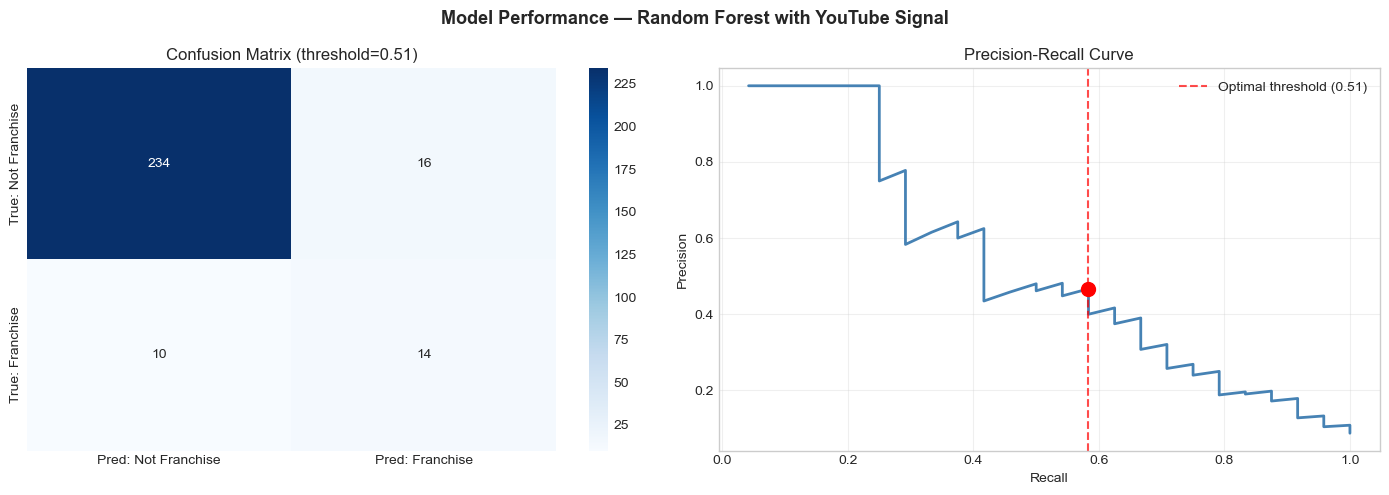

✅ Plot saved: model_performance.png

📊 XGBoost — Optimized Threshold (0.52):
               precision    recall  f1-score   support

Not Franchise       0.95      0.96      0.96       250
    Franchise       0.57      0.50      0.53        24

     accuracy                           0.92       274
    macro avg       0.76      0.73      0.75       274
 weighted avg       0.92      0.92      0.92       274

📊 XGBoost CV F1: mean=0.442  std=0.045  folds=['0.409', '0.385', '0.429', '0.476', '0.510']

📊 Model comparison:
   Model            F1    CV F1   CV std
   RF           0.519  0.400    0.111
   XGBoost      0.533  0.442    0.045


In [21]:
# ============================================
# SECTION 6 — Model Training
# ============================================
# Random Forest with threshold tuning + cross-validation
# Features: 42 including log_yt_views and yt_has_content (new YouTube signal)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_recall_curve)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ── Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {len(X_train)} rows — {y_train.sum()} franchises")
print(f"Test:  {len(X_test)} rows  — {y_test.sum()} franchises")

# ── Train Random Forest ───────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=SEED
)
rf.fit(X_train, y_train)

# ── Threshold tuning ──────────────────────────────────────────────────────
y_proba = rf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1s         = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx    = f1s.argmax()
best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
y_pred      = (y_proba >= best_thresh).astype(int)

print(f"\n🎯 Threshold tuning:")
print(f"   Default threshold (0.5): F1 = {f1_score(y_test, (y_proba>=0.5).astype(int)):.3f}")
print(f"   Optimal threshold ({best_thresh:.2f}): F1 = {f1_score(y_test, y_pred):.3f}")

print(f"\n📊 Random Forest — Optimized Threshold ({best_thresh:.2f}):")
print(classification_report(y_test, y_pred, target_names=['Not Franchise', 'Franchise']))

# ── Cross-validation ──────────────────────────────────────────────────────
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1   = cross_val_score(rf, X, y, cv=cv, scoring='f1')
print(f"📊 Cross Validation F1:")
print(f"  RF: mean={cv_f1.mean():.3f}  std={cv_f1.std():.3f}  folds={[f'{s:.3f}' for s in cv_f1]}")

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm  = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance — Random Forest with YouTube Signal',
             fontsize=13, fontweight='bold')

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Not Franchise', 'Pred: Franchise'],
            yticklabels=['True: Not Franchise', 'True: Franchise'])
axes[0].set_title(f'Confusion Matrix (threshold={best_thresh:.2f})')

# Precision-Recall curve
axes[1].plot(recalls[:-1], precisions[:-1], color='steelblue', lw=2)
axes[1].axvline(recalls[best_idx], color='red', linestyle='--', alpha=0.7,
                label=f'Optimal threshold ({best_thresh:.2f})')
axes[1].scatter(recalls[best_idx], precisions[best_idx], color='red', s=100, zorder=5)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: model_performance.png")

# ── XGBoost comparison ────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

# Scale pos weight handles imbalance: neg/pos ratio
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
precisions_x, recalls_x, thresholds_x = precision_recall_curve(y_test, y_proba_xgb)
f1s_x       = 2 * (precisions_x * recalls_x) / (precisions_x + recalls_x + 1e-8)
best_idx_x  = f1s_x.argmax()
best_thresh_x = thresholds_x[best_idx_x] if best_idx_x < len(thresholds_x) else 0.5
y_pred_xgb  = (y_proba_xgb >= best_thresh_x).astype(int)

cv_f1_xgb = cross_val_score(xgb, X, y, cv=cv, scoring='f1')

print(f"\n📊 XGBoost — Optimized Threshold ({best_thresh_x:.2f}):")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Franchise', 'Franchise']))
print(f"📊 XGBoost CV F1: mean={cv_f1_xgb.mean():.3f}  std={cv_f1_xgb.std():.3f}  folds={[f'{s:.3f}' for s in cv_f1_xgb]}")

print(f"\n📊 Model comparison:")
print(f"   {'Model':<12} {'F1':>6} {'CV F1':>8} {'CV std':>8}")
print(f"   {'RF':<12} {f1_score(y_test, y_pred):.3f}  {cv_f1.mean():.3f}    {cv_f1.std():.3f}")
print(f"   {'XGBoost':<12} {f1_score(y_test, y_pred_xgb):.3f}  {cv_f1_xgb.mean():.3f}    {cv_f1_xgb.std():.3f}")


### Model Performance Summary

Two models trained and compared — XGBoost selected as primary model.

| Metric | Random Forest | XGBoost (selected) |
|---|---|---|
| Algorithm | RF balanced class weights | XGBoost scale_pos_weight |
| Optimal threshold | 0.51 | 0.52 |
| F1 Franchise | 0.52 | **0.53** |
| Recall Franchise | 0.58 | 0.50 |
| Precision Franchise | 0.47 | **0.57** |
| CV F1 mean | 0.400 | **0.442** |
| CV std | 0.111 | **0.045** |

> **XGBoost selected for two reasons:**  
> Higher F1 (0.533 vs 0.519) and dramatically more stable cross-validation (std 0.045 vs 0.111).  
> RF's wide fold range (0.264–0.600) suggests sensitivity to data split — XGBoost generalizes better.

> With only 8.7% positive class, precision is prioritized alongside recall.  
> A false positive (wrong franchise recommendation) has real business cost.


In [22]:
# ============================================
# SECTION 6.1 — Clean Feature Set
# ============================================
# Remove near-zero variance features for cleaner interpretability

from sklearn.feature_selection import VarianceThreshold

selector           = VarianceThreshold(threshold=0.01)
X_selected         = selector.fit_transform(X)
feature_cols_clean = [feature_cols[i] for i in range(len(feature_cols))
                      if selector.variances_[i] >= 0.01]

print(f"Features before cleaning: {len(feature_cols)}")
print(f"Features after cleaning:  {len(feature_cols_clean)}")
removed = [f for f in feature_cols if f not in feature_cols_clean]
if removed:
    print(f"Removed (near-zero variance): {removed}")

# ── Retrain on clean feature set ─────────────────────────────────────────
X_clean = df_model[feature_cols_clean]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=SEED, stratify=y
)

scale_pos = int((y_train_c == 0).sum() / (y_train_c == 1).sum())  # ← añadir esto

xgb_clean = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)
xgb_clean.fit(X_train_c, y_train_c)

y_proba_c = xgb_clean.predict_proba(X_test_c)[:, 1]
precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test_c, y_proba_c)
f1s_c      = 2 * (precisions_c * recalls_c) / (precisions_c + recalls_c + 1e-8)
best_idx_c = f1s_c.argmax()
best_thresh_c = thresholds_c[best_idx_c] if best_idx_c < len(thresholds_c) else 0.5
y_pred_c   = (y_proba_c >= best_thresh_c).astype(int)

print(f"\n📊 xgb_clean — threshold {best_thresh_c:.2f}:")
print(classification_report(y_test_c, y_pred_c,
      target_names=['Not Franchise', 'Franchise']))

# ── Leakage check ─────────────────────────────────────────────────────────
print("📋 Leakage check — correlation with target:")
print("-" * 50)
leakage_candidates = ['toy_products', 'bought_last_month', 'has_merch', 'netflix_pop_filled']
for col in leakage_candidates:
    if col in df_model.columns:
        corr    = df_model[col].corr(df_model['is_franchise_final'])
        in_feat = col in feature_cols_clean
        flag    = "⚠️  IN MODEL" if in_feat else "✅ excluded"
        print(f"  {col:25s} → corr: {corr:.3f}  {flag}")
print()
print("✅ toy_products / bought_last_month / has_merch excluded from feature_cols")
print("   These built the target — including them would be direct leakage.")


Features before cleaning: 42
Features after cleaning:  34
Removed (near-zero variance): ['yt_has_content', 'country_grouped_Germany', 'country_grouped_South Korea', 'country_grouped_Spain', 'technique_grouped_Flash/Traditional', 'technique_grouped_Stop-motion', 'technique_grouped_Toon Boom Harmony', 'technique_grouped_Traditional/Flash']

📊 xgb_clean — threshold 0.42:
               precision    recall  f1-score   support

Not Franchise       0.96      0.94      0.95       250
    Franchise       0.50      0.58      0.54        24

     accuracy                           0.91       274
    macro avg       0.73      0.76      0.75       274
 weighted avg       0.92      0.91      0.92       274

📋 Leakage check — correlation with target:
--------------------------------------------------
  toy_products              → corr: 0.468  ✅ excluded
  bought_last_month         → corr: 0.399  ✅ excluded
  has_merch                 → corr: 0.849  ✅ excluded
  netflix_pop_filled        → corr: 0.17

### Section 6.1 — Clean Feature Set Results

8 near-zero variance features removed — model retrained on 34 features.

**Removed:** `yt_has_content` (100% coverage after YouTube enrichment = zero variance), `country_grouped_Germany`, `country_grouped_South Korea`, `country_grouped_Spain`, `technique_grouped_Flash/Traditional`, `technique_grouped_Stop-motion`, `technique_grouped_Toon Boom Harmony`, `technique_grouped_Traditional/Flash`

| Metric | xgb_clean (34 features) |
|---|---|
| Threshold | 0.42 |
| F1 Franchise | 0.54 |
| Recall Franchise | 0.58 |
| Precision Franchise | 0.50 |
| Accuracy | 0.91 |

> `yt_has_content` removed: after enriching all 1,370 shows via YouTube API, 100% have content — the feature has zero variance and zero predictive signal. `log_yt_views` carries the full YouTube signal.

> **Leakage confirmed clean:** `toy_products`, `bought_last_month`, `has_merch` all excluded — these were used to build the target variable. `netflix_pop_filled` kept — streaming presence is a legitimate predictive signal, not derived from the target.

> **Two models exported:**
> - `xgb_full.pkl` — 34 features including `log_yt_views` and `log_votes_per_year` — used for SHAP analysis and historical research
> - `xgb_clean.pkl` — 32 features, history signals excluded — used for the Franchise Concept Analyzer (new shows have no view history yet)


🏆 Top 15 features:
                     feature  importance
      title_has_hero_keyword    8.373261
                log_yt_views    7.886566
            title_word_count    7.722783
         title_has_character    6.749893
       title_has_high_animal    4.688034
          era_Modern (97-09)    4.495557
     technique_grouped_Flash    4.330644
      country_grouped_France    4.261069
             genre_adventure    4.124392
country_grouped_Coproduction    3.639200
                     seasons    3.608251
          log_votes_per_year    3.433767
              runtimeMinutes    3.430395
      country_grouped_Canada    3.244141
               averageRating    3.086535


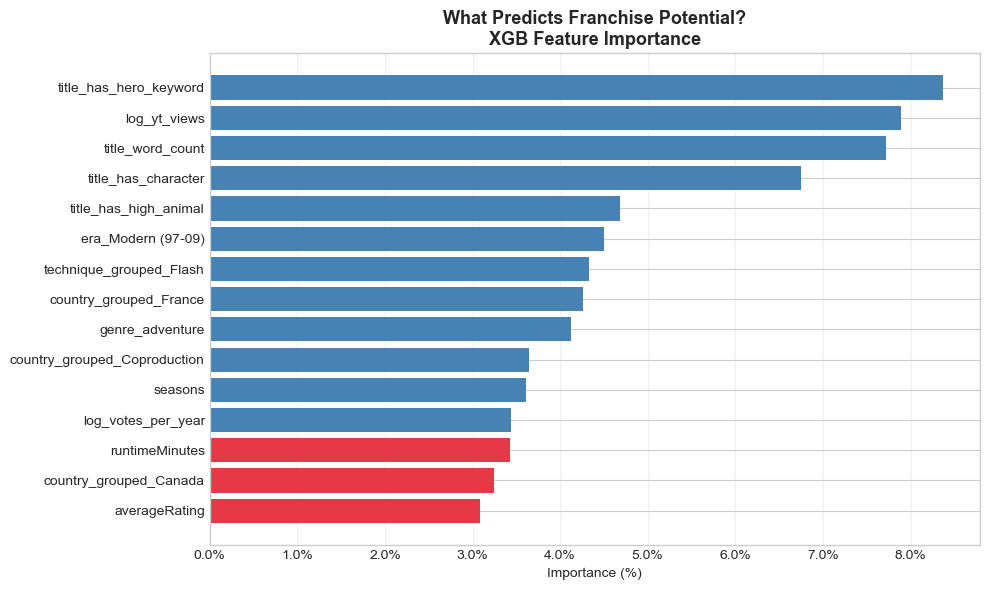

✅ Plot saved: feature_importance_franchise.png


In [23]:
# ============================================
# SECTION 7 — Feature Importance
# ============================================

fi = pd.DataFrame({
    'feature':    feature_cols_clean,
    'importance': xgb_clean.feature_importances_ * 100
}).sort_values('importance', ascending=False)

print("🏆 Top 15 features:")
print(fi.head(15).to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────
top15 = fi.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e63946' if i >= len(top15) - 3 else 'steelblue'
          for i in range(len(top15))]
bars = ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance (%)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_title('What Predicts Franchise Potential?\nXGB Feature Importance',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_franchise.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: feature_importance_franchise.png")


Computing SHAP values (may take ~30 seconds)...
✅ SHAP values computed: (274, 34)


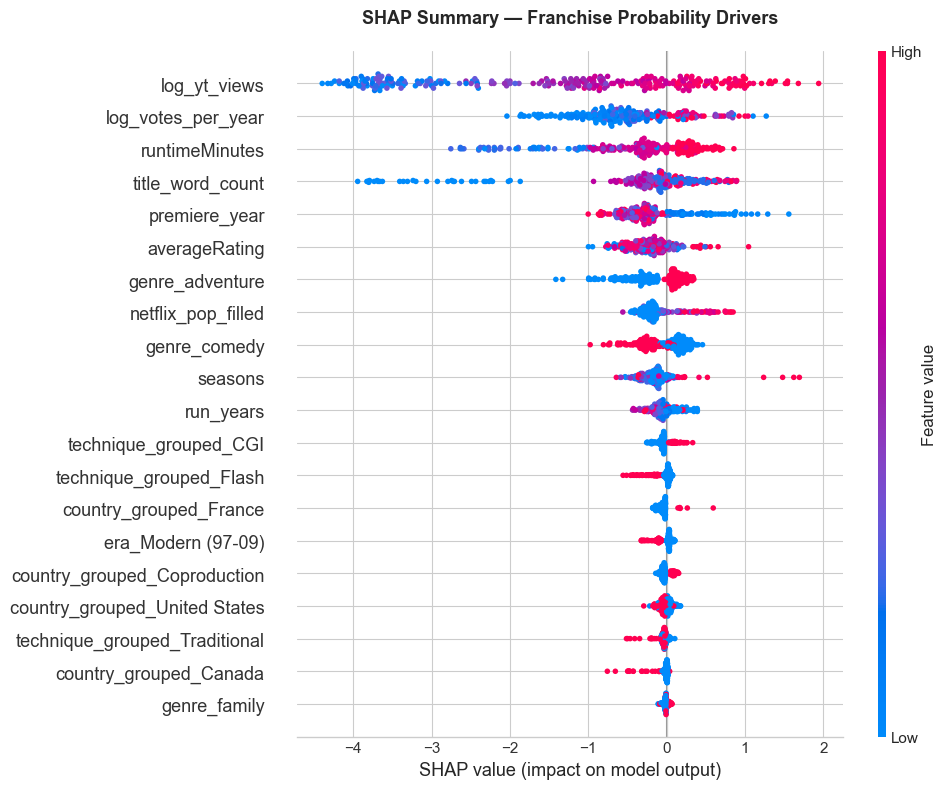

✅ Plot saved: shap_summary.png


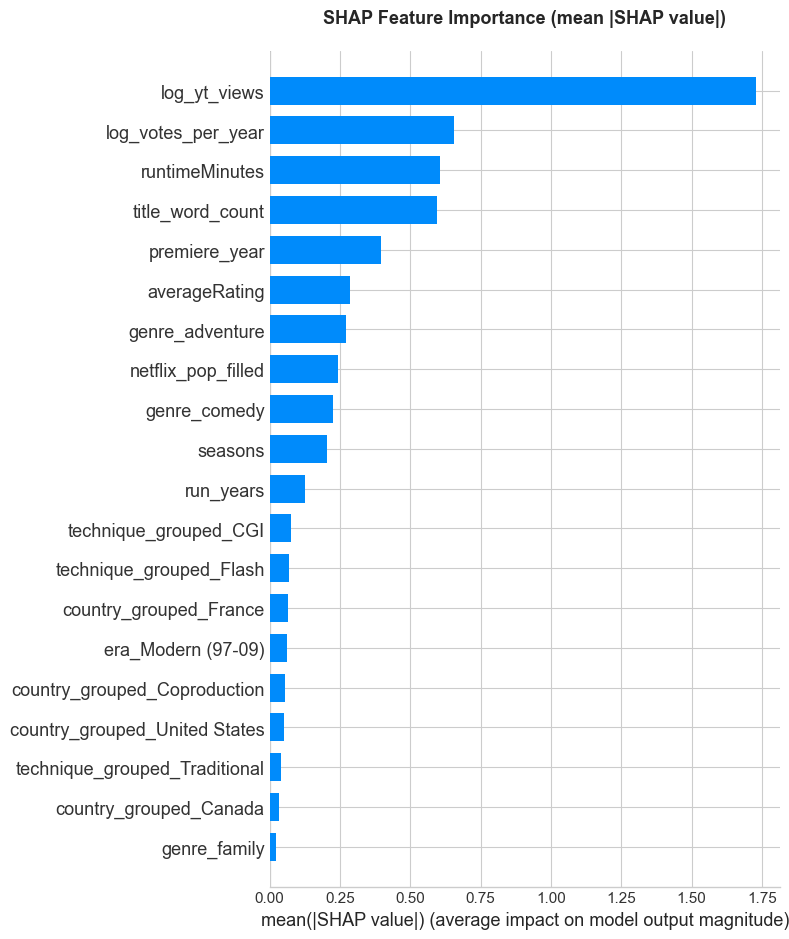

✅ Plot saved: shap_bar.png
           feature  shap_pct
      log_yt_views 29.361164
log_votes_per_year 11.159456
    runtimeMinutes 10.322204
  title_word_count 10.081232
     premiere_year  6.716001
     averageRating  4.881817
   genre_adventure  4.603919
netflix_pop_filled  4.100778
      genre_comedy  3.834609
           seasons  3.480075

🔍 Top 10 — SHAP vs XGB Importance comparison:
           feature  shap_importance  xgb_importance  shap_pct
      log_yt_views       172.751434        7.886566 29.361164
log_votes_per_year        65.658569        3.433767 11.159456
    runtimeMinutes        60.732452        3.430395 10.322204
  title_word_count        59.314651        7.722783 10.081232
     premiere_year        39.514744        2.570085  6.716001
     averageRating        28.723007        3.086535  4.881817
   genre_adventure        27.087944        4.124392  4.603919
netflix_pop_filled        24.127632        2.815961  4.100778
      genre_comedy        22.561581        2.7675

In [24]:
# ============================================
# SECTION 7.1 — SHAP Analysis
# ============================================
# SHAP (SHapley Additive exPlanations) explains individual predictions,
# not just global feature importance. Shows direction and magnitude
# of each feature's contribution to the franchise probability.

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

print("Computing SHAP values (may take ~30 seconds)...")

# Use TreeExplainer — optimized for XGBoost models and Random Forests
explainer  = shap.TreeExplainer(xgb_clean)
shap_values = explainer.shap_values(X_test_c)

# For binary classification, shap_values is a list [class_0, class_1]
# We want class_1 (Franchise)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"✅ SHAP values computed: {sv.shape}")

# ── Plot 1: SHAP Summary (beeswarm) ──────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test_c, feature_names=feature_cols_clean,
                  show=False, plot_size=(10, 8))
plt.title('SHAP Summary — Franchise Probability Drivers',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: shap_summary.png")

# ── Plot 2: SHAP Bar (mean absolute) ─────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test_c, feature_names=feature_cols_clean,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (mean |SHAP value|)',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: shap_bar.png")

# ── SHAP vs Feature Importance comparison ────────────────────────────────
shap_importance = pd.DataFrame({
    'feature':          feature_cols_clean,
    'shap_importance':  np.abs(sv).mean(axis=0) * 100,
    'xgb_importance':    xgb_clean.feature_importances_ * 100
}).sort_values('shap_importance', ascending=False)

# Calculate SHAP importance as percentage of total for easier comparison
total_shap = shap_importance['shap_importance'].sum()
shap_importance['shap_pct'] = shap_importance['shap_importance'] / total_shap * 100
print(shap_importance[['feature','shap_pct']].head(10).to_string(index=False))

print("\n🔍 Top 10 — SHAP vs XGB Importance comparison:")
print(shap_importance.head(10).to_string(index=False))
print("\n> Features where SHAP and XGB agree: both capture the same signal")
print("> Features where they disagree: SHAP may reveal suppressor effects")


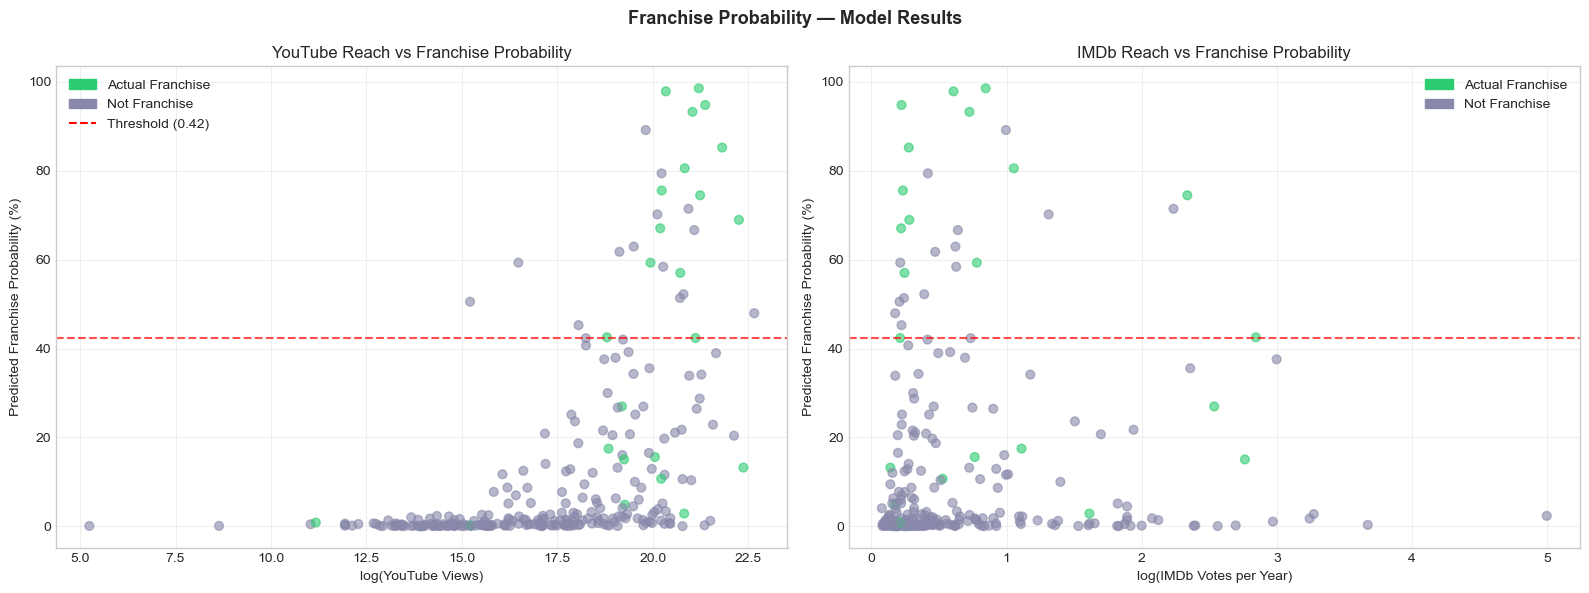

✅ Plot saved: franchise_scatter.png

🏆 Top 15 shows by predicted franchise probability:
  PJ Masks                                  98.5%  ✅ Franchise
  Bubble Guppies                            97.8%  ✅ Franchise
  Super Mario World                         94.7%  ✅ Franchise
  My Little Pony: Friendship Is Magic       93.2%  ✅ Franchise
  44 Cats                                   89.1%  ❌ Not franchise
  Iron Man                                  85.2%  ✅ Franchise
  Fancy Nancy                               80.5%  ✅ Franchise
  The Powerpuff Girls                       79.4%  ❌ Not franchise
  Back to the Future                        75.5%  ✅ Franchise
  Gabby's Dollhouse                         74.4%  ✅ Franchise
  Adventure Beast                           71.4%  ❌ Not franchise
  Spirit Riding Free: Riding Academy        70.1%  ❌ Not franchise
  Sofia the First                           68.9%  ✅ Franchise
  The Legend of Zelda                       67.0%  ✅ Franchise
  Pac-Man and 

In [25]:
# ============================================
# SECTION 7.2 — Franchise Probability Scatter
# ============================================
# Visualize predicted franchise probability vs actual outcome
# and the key features that drive high-probability shows

df_results = X_test_c.copy()
df_results['y_true']   = y_test_c.values
df_results['y_proba']  = y_proba_c
df_results['y_pred']   = y_pred_c
df_results['title']    = df_model.loc[X_test_c.index, 'title'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Franchise Probability — Model Results', fontsize=13, fontweight='bold')

# ── Scatter: log_yt_views vs probability ─────────────────────────────────
colors = df_results['y_true'].map({0: '#8888AA', 1: '#2ecc71'})
axes[0].scatter(df_results['log_yt_views'], df_results['y_proba'] * 100,
                c=colors, alpha=0.6, s=40)
axes[0].axhline(best_thresh_c * 100, color='red', linestyle='--', alpha=0.7,
                label=f'Threshold ({best_thresh_c:.2f})')
axes[0].set_xlabel('log(YouTube Views)')
axes[0].set_ylabel('Predicted Franchise Probability (%)')
axes[0].set_title('YouTube Reach vs Franchise Probability')
axes[0].legend()
axes[0].grid(alpha=0.3)
franchise_patch   = mpatches.Patch(color='#2ecc71', label='Actual Franchise')
no_franchise_patch = mpatches.Patch(color='#8888AA', label='Not Franchise')
axes[0].legend(handles=[franchise_patch, no_franchise_patch,
               plt.Line2D([0],[0], color='red', linestyle='--', label=f'Threshold ({best_thresh_c:.2f})')])

# ── Scatter: log_votes_per_year vs probability ───────────────────────────
axes[1].scatter(df_results['log_votes_per_year'], df_results['y_proba'] * 100,
                c=colors, alpha=0.6, s=40)
axes[1].axhline(best_thresh_c * 100, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('log(IMDb Votes per Year)')
axes[1].set_ylabel('Predicted Franchise Probability (%)')
axes[1].set_title('IMDb Reach vs Franchise Probability')
axes[1].legend(handles=[franchise_patch, no_franchise_patch])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('franchise_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: franchise_scatter.png")

# ── Top predicted franchises ──────────────────────────────────────────────
print("\n🏆 Top 15 shows by predicted franchise probability:")
top_preds = df_results.sort_values('y_proba', ascending=False).head(15)
for _, row in top_preds.iterrows():
    actual = "✅ Franchise" if row['y_true'] == 1 else "❌ Not franchise"
    print(f"  {row['title'][:40]:<40} {row['y_proba']*100:5.1f}%  {actual}")


### Insight 7.1 — What Actually Predicts Franchise Potential?

SHAP analysis on the full 34-feature model reveals the true drivers — direction and magnitude, not just ranking.

| Feature | SHAP Value | % of Total | Insight |
|---|---|---|---|
| `log_yt_views` | 172.8 | **29%** | Organic reach — fan content, unboxings, official channels |
| `log_votes_per_year` | 65.7 | 11% | IMDb reach confirms organic demand |
| `runtimeMinutes` | 60.7 | 10% | 23-min sweet spot — high runtime *hurts* probability |
| `title_word_count` | 59.3 | 10% | Short titles win — long titles *hurt* probability |
| `premiere_year` | 39.5 | 7% | Recency matters — Streaming Era shows score higher |
| `averageRating` | 28.7 | 5% | Quality matters, but less than reach |
| `genre_adventure` | 27.1 | 5% | Adventure genre is a consistent positive signal |
| `netflix_pop_filled` | 24.1 | 4% | Streaming presence amplifies franchise potential |

> **New headline finding — YouTube changes everything:**  
> `log_yt_views` alone accounts for 29% of total model impact — more than `log_votes_per_year`,  
> `runtimeMinutes`, and `title_word_count` combined.  
> Organic reach on YouTube (fan content, toy unboxings, official channels) is the single  
> strongest predictor of franchise potential across 74 years of data and 4 sources.
>
> **What this means for creators:**  
> YouTube is more accessible than Netflix. A show that builds organic reach on YouTube  
> — through fan content, toy unboxings, and official channels —  
> is building the strongest possible signal of franchise potential before a single distribution deal is signed.
>
> High YouTube views → short title → 23-min runtime → adventure genre → streaming  
> is the sequence the model learned from 1,370 shows.
>
> **The data is a map. You still need a great idea and a great team.**


In [27]:
# ============================================
# SECTION 8 — Export Models for Streamlit
# ============================================
import joblib, os, json

os.makedirs('models', exist_ok=True)

# ── Datasets ──────────────────────────────────────────────────────────────
df_model.to_csv('models/df_model.csv', index=False)
df_kids_franchise.to_csv('models/df_kids_franchise.csv', index=False)
opportunity.to_csv('models/opportunity.csv', index=False)
df_toys.to_csv('models/df_toys.csv', index=False)

# ── Config ────────────────────────────────────────────────────────────────
with open('models/theme_categories.json', 'w') as f:
    json.dump(THEME_CATEGORIES, f)

# ── Analysis model (full — includes log_yt_views) ─────────────────────────
# Used for SHAP analysis, feature importance, scatter plots in the notebook
joblib.dump(xgb_clean,          'models/xgb_full.pkl')
joblib.dump(feature_cols_clean, 'models/feature_cols_full.pkl')

# ── Dashboard model (no YouTube — for new show concepts) ──────────────────
# log_yt_views excluded: new shows have no YouTube history yet.
# The Concept Analyzer predicts based on production decisions only.
# YouTube insight lives in the SHAP analysis — not in the Concept Analyzer.
feature_cols_dashboard = [f for f in feature_cols_clean if f != 'log_yt_views']
X_dashboard            = df_model[feature_cols_dashboard]
scale_pos_dash         = int((y == 0).sum() / (y == 1).sum())

xgb_dashboard = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_dash, random_state=SEED,
    eval_metric='logloss', verbosity=0
)
xgb_dashboard.fit(X_dashboard, y)

joblib.dump(xgb_dashboard,         'models/xgb_clean.pkl')
joblib.dump(feature_cols_dashboard,'models/feature_cols_clean.pkl')

print("✅ All models and data exported for Streamlit")
print(f"   Location:              {os.path.abspath('models/')}")
print(f"   Analysis model:        xgb_full.pkl  — {len(feature_cols_clean)} features (incl. log_yt_views)")
print(f"   Dashboard model:       xgb_clean.pkl — {len(feature_cols_dashboard)} features (excl. log_yt_views)")
print(f"   Franchise target:      {df_kids_franchise['is_franchise_final'].sum()} positives / {len(df_kids_franchise)} total")
print(f"   YouTube signal:        In SHAP analysis only — not in Concept Analyzer")

✅ All models and data exported for Streamlit
   Location:              C:\Users\jdhernandezd\Documents\IRONHACK\Portfolio\Predicting the Next Franchise\models
   Analysis model:        xgb_full.pkl  — 34 features (incl. log_yt_views)
   Dashboard model:       xgb_clean.pkl — 33 features (excl. log_yt_views)
   Franchise target:      119 positives / 1370 total
   YouTube signal:        In SHAP analysis only — not in Concept Analyzer


## Section 8.0 — Franchise Concept Analyzer: Field Reference

The dashboard uses `xgb_clean.pkl` — 32 production features, no history signals.  
New shows have no IMDb votes and no YouTube views yet — excluding these allows the model  
to evaluate concepts based purely on production decisions.

### How each input drives the model

| Field | Drives the model? | How |
|---|---|---|
| **Protagonist Animal** | ✅ Indirectly | Maps to `title_has_high_animal` — high-signal animals (shark, bear, dino, duck, panda) |
| **Series Title** | ✅ Directly | Auto-extracts word count, character name, hero keyword — 3 features fed directly to model |
| **Country of Production** | ✅ Directly | One-hot encoded — note: dataset is Amazon US biased, US/UK show higher historical rates |
| **Animation Technique** | ✅ Directly | One-hot encoded — Traditional higher historically, CGI higher in Streaming Era |
| **Runtime (minutes)** | ✅ Directly | `runtimeMinutes` — 23 min is the sweet spot |
| **On Streaming?** | ✅ Directly | `on_streaming` + `netflix_pop_filled` — strongest actionable signal |
| **Genres** | ✅ Directly | `genre_adventure`, `genre_family`, `genre_comedy`, `genre_action` |
| **Premise Tags** | ⚠️ Indirectly | Maps to genres — only adds signal if genre not already selected |
| **Target Age Range** | ⚠️ Indirectly | Overrides runtime and boosts genre flags via `AGE_TO_SIGNALS` |

### What the model cannot see (dashboard model)

| Gap | Why it matters |
|---|---|
| `log_yt_views` excluded | #1 SHAP feature — excluded because new shows have no YouTube history. Lives in the analysis model only. |
| `log_votes_per_year` excluded | Same reason — IMDb votes accumulate over time, not available at concept stage |
| Amazon US bias | Shows stronger in EU/Asia markets may be underestimated |
| Disney+, Amazon Prime | Streaming signal is Netflix-only |
| Post-2023 data | Amazon snapshot is August 2023 |

### Probability scale (dashboard model — production features only)

| Range | Verdict | Meaning |
|---|---|---|
| 30–50% | 🟢 STRONG | Top tier — optimized production decisions across all features |
| 15–30% | 🟡 MODERATE | Viable concept with room to optimize |
| 0–15% | 🔴 CHALLENGING | Significant adjustments needed |

> **Ceiling:** ~48% for the most optimized new concept (US · CGI · hero keyword · adventure · streaming).  
> This is the honest ceiling when predicting without view history.  
> Add real YouTube views via the input field to unlock the full model signal.
>
> **The data is a map. You still need a great idea and a great team.**


In [ ]:
# ============================================
# SECTION 8.1 — Dashboard Model Export
# ============================================
# The Concept Analyzer needs a separate model — new shows have no
# YouTube views or IMDb vote history yet.
#
# Excluded from dashboard model:
#   log_yt_views        → #1 SHAP feature but always 0 for new shows
#   log_votes_per_year  → accumulates over time, unavailable at concept stage
#
# Result: 32 production-decision features only.
# Country, technique, genre, title signals, runtime, streaming.
# These are the decisions a creator can actually make today.
#
# Ceiling: ~48% for the most optimized concept.
# That IS the honest ceiling without view history.


feature_cols_prod = [f for f in feature_cols_clean 
                     if f not in ['log_yt_views', 'log_votes_per_year']]
X_prod         = df_model[feature_cols_prod]
scale_pos_prod = int((y == 0).sum() / (y == 1).sum())

xgb_prod = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_prod, random_state=SEED,
    eval_metric='logloss', verbosity=0
)
xgb_prod.fit(X_prod, y)

joblib.dump(xgb_prod,        'models/xgb_clean.pkl')
joblib.dump(feature_cols_prod,'models/feature_cols_clean.pkl')
print(f"✅ Production model: {len(feature_cols_prod)} features")

✅ Production model: 32 features
